## 1. Data Integration, Multi-Source Merging & Provenance Tracking
*Objective: Executing robust data joins across metadata and labeling sources while logging absolute row transformation drops.*

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Tắt toàn bộ thông báo chữ đỏ để notebook sạch đẹp 100%
warnings.filterwarnings('ignore')

# =========================================================================
# 🛠️ SYSTEM CONFIGURATION
# =========================================================================
META_PATH = '/kaggle/input/datasets/ndhoang2310/eyes-blink-datasetdap-project/dataset_master/metadata.csv'
LABEL_PATH = '/kaggle/input/datasets/ndhoang2310/eyes-blink-datasetdap-project/dataset_master/labels.csv'
OUTPUT_DIR = 'charts'

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100 
plt.rcParams['font.family'] = 'sans-serif'

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# =========================================================================
# BƯỚC 1: TẢI DATASET THÔ & KIỂM TRA DỮ LIỆU KHUYẾT (NaN)
# =========================================================================
print("--- [TRACKING 1] Checking Initial Raw Dataset Sizes ---")
df_meta = pd.read_csv(META_PATH)
df_labels = pd.read_csv(LABEL_PATH)

print(f"1. Total rows in raw metadata.csv : {df_meta.shape[0]} rows")
print(f"2. Total rows in raw labels.csv   : {df_labels.shape[0]} rows")

print("\n--- [TRACKING 2] Detecting Missing Values (None/NaN) Before Processing ---")
print(f"  - Missing 'image_path' in Metadata: {df_meta['image_path'].isnull().sum()} rows")
print(f"  - Missing 'video_id' in Metadata  : {df_meta['video_id'].isnull().sum()} rows")
print(f"  - Missing 'ear_left' in Metadata  : {df_meta['ear_left'].isnull().sum()} rows")
print(f"  - Missing 'label' in Labels       : {df_labels['label'].isnull().sum()} rows")

# Sao lưu lại các dòng thiếu đường dẫn để in kiểm tra trước khi drop hẳn
df_missing_path_raw = df_meta[df_meta['image_path'].isnull()].copy()

# Làm sạch hàng trống trên Metadata dựa trên image_path
df_meta = df_meta.dropna(subset=['image_path'])
df_meta['image_path'] = df_meta['image_path'].astype(str)

# Chuẩn hóa khóa 'filename' để chuẩn bị gộp bảng
df_meta['filename'] = df_meta['image_path'].apply(lambda x: os.path.basename(str(x)))
df_labels['filename'] = df_labels['filename'].apply(lambda x: os.path.basename(str(x)))

# =========================================================================
# BƯỚC 2: TIẾN HÀNH INNER JOIN GỘP BẢNG DỮ LIỆU
# =========================================================================
print("\n--- [TRACKING 3] Executing Data Merging (Inner Join) ---")
df_merged_raw = pd.merge(df_meta, df_labels, on='filename', how='inner')
print(f"3. Size directly AFTER INNER MERGE: {df_merged_raw.shape[0]} rows")
print(f"   -> Dropped rows due to filename mismatch: {df_labels.shape[0] - df_merged_raw.shape[0]} rows")

# Tách mã member_id phục vụ việc gom cụm phân tích đặc biệt
df_merged_raw['member_id'] = df_merged_raw['video_id'].apply(lambda x: str(x).split('_')[0])

# =========================================================================
# BƯỚC 3: TRUY VẾT CÁC KHUNG HÌNH BỊ CHE MẮT / MỒ CÔI (OCCLUSION)
# =========================================================================
print("\n--- [SPECIAL TRACING] Detecting Single-Eye Frames (Hand Occlusion / Extreme Angles) ---")
# Đếm số lượng mắt xuất hiện trong cùng một frame của một video
frame_counts = df_merged_raw.groupby(['video_id', 'frame_index']).size().reset_index(name='eye_count')

# Khung hình mồ côi là khung hình chỉ xuất hiện đúng 1 lần thay vì 2 lần (Trái + Phải)
single_eye_frames = frame_counts[frame_counts['eye_count'] == 1]
print(f"👉 Identified exactly: {len(single_eye_frames)} unique frames containing only ONE tracked eye.")

# =========================================================================
# BƯỚC 4: LỌC TRÙNG LẶP ĐỊNH DANH ĐỂ ĐỒNG BỘ CHUỖI THỜI GIAN
# =========================================================================
print("\n--- [TRACKING 4] Removing Temporal Duplicates (Merging Left & Right Eye Rows) ---")
duplicate_count = df_merged_raw.duplicated(subset=['video_id', 'frame_index']).sum()
print(f"4. Number of duplicated rows detected (Dual-Eye redundancy): {duplicate_count} rows")

df_merged = df_merged_raw.drop_duplicates(subset=['video_id', 'frame_index'])
print(f"5. Final size after DROP DUPLICATES  : {df_merged.shape[0]} rows (Unique Time Frames)")

# =========================================================================
# BƯỚC 5: CHUẨN HÓA NHÃN CHỮ THÀNH SỐ CHUẨN (MAPPING LABELS)
# =========================================================================
df_merged['label_clean'] = df_merged['label'].astype(str).str.lower().str.strip()
df_merged['label_numeric'] = df_merged['label_clean'].map({'open': 1, 'closed': 0, '1': 1, '0': 0})

print("\n--- [TRACKING 5] Verifying Label Quality ---")
invalid_labels_count = df_merged['label_numeric'].isnull().sum()
print(f"  - Number of corrupted/invalid labels: {invalid_labels_count} rows")

# Áp dụng nhãn số nhị phân sạch
df_merged['label'] = df_merged['label_numeric']
df_merged = df_merged.dropna(subset=['label'])
df_merged['label'] = df_merged['label'].astype(int)

print("\n" + "="*75)
print(f"[SUCCESS] PREPROCESSING & QUALITY CONTROL COMPLETED!")
print(f"👉 TOTAL CLEAN FRAMES READY FOR ENGLISH EDA PLOTTING: {df_merged.shape[0]} rows")
print("="*75)

--- [TRACKING 1] Checking Initial Raw Dataset Sizes ---
1. Total rows in raw metadata.csv : 16616 rows
2. Total rows in raw labels.csv   : 16440 rows

--- [TRACKING 2] Detecting Missing Values (None/NaN) Before Processing ---
  - Missing 'image_path' in Metadata: 132 rows
  - Missing 'video_id' in Metadata  : 0 rows
  - Missing 'ear_left' in Metadata  : 132 rows
  - Missing 'label' in Labels       : 0 rows

--- [TRACKING 3] Executing Data Merging (Inner Join) ---
3. Size directly AFTER INNER MERGE: 16440 rows
   -> Dropped rows due to filename mismatch: 0 rows

--- [SPECIAL TRACING] Detecting Single-Eye Frames (Hand Occlusion / Extreme Angles) ---
👉 Identified exactly: 28 unique frames containing only ONE tracked eye.

--- [TRACKING 4] Removing Temporal Duplicates (Merging Left & Right Eye Rows) ---
4. Number of duplicated rows detected (Dual-Eye redundancy): 8206 rows
5. Final size after DROP DUPLICATES  : 8234 rows (Unique Time Frames)

--- [TRACKING 5] Verifying Label Quality ---
  

## 2. Temporal Analysis & Sequential Closed-Eye Distribution
*Objective: Analyzing the frequency and duration of consecutive closed-frame sequences to define real-time constraints.*

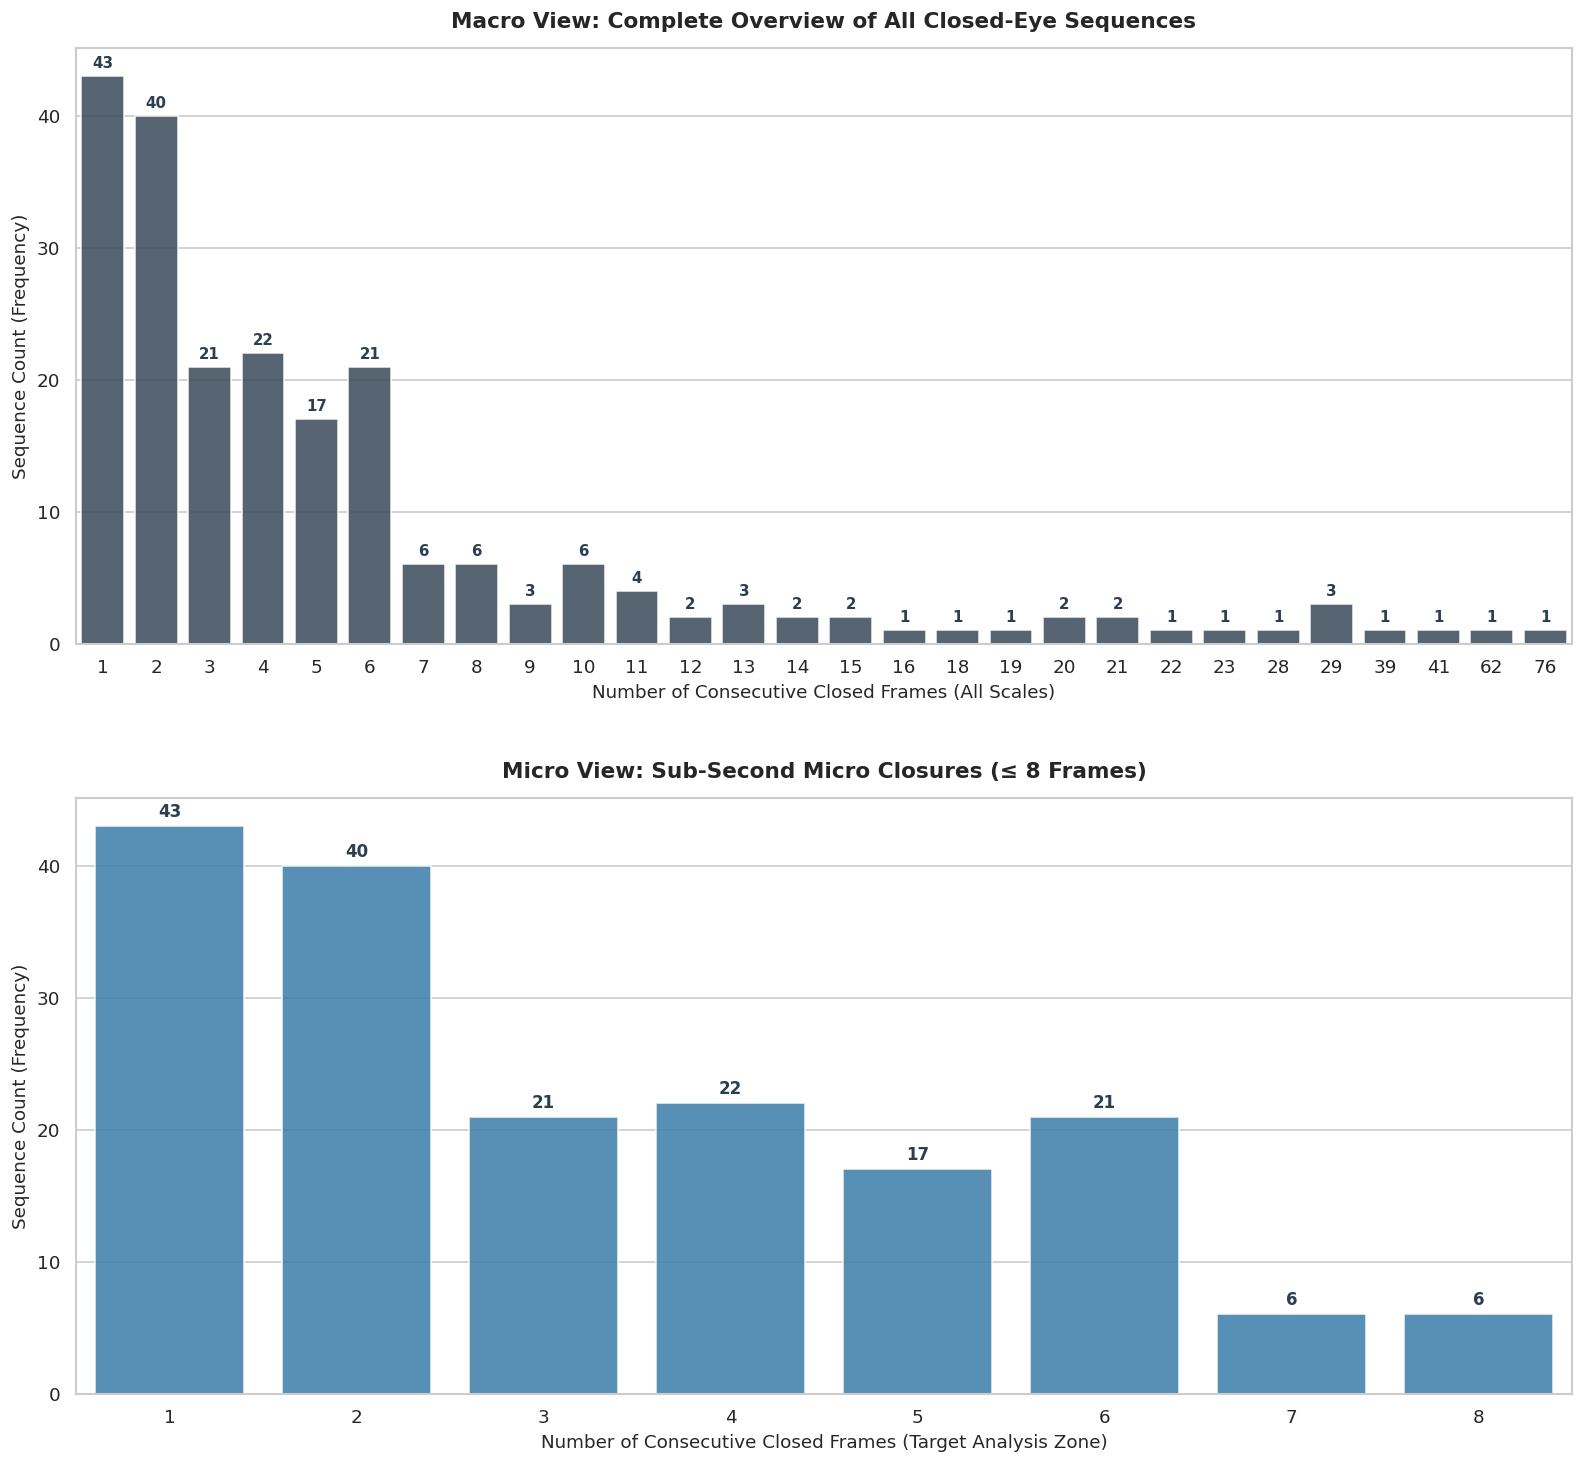


  📊 MICRO CLOSED FRAMES STATISTICAL REPORT (BASED EXCLUSIVELY ON ≤ 8 FRAMES)
 • Minimum Closed Sequence Length : 1 frame
 • Maximum Closed Sequence Length : 8 frames
 • Median Closed Sequence Length  : 3 frames
 • Mean Closed Sequence Length    : 3.27 frames
----------------------------------------------------------------------
                    💡 REAL-TIME SYSTEM OPTIMIZATION                     
----------------------------------------------------------------------
 • Recommended Sliding Window Size: 7 Frames
 • Equivalent Time Duration       : 0.47 seconds (@15 FPS)



In [2]:

# 1. Thuật toán gom cụm chuỗi thời gian tuần tự (Nguyên bản)
df_ts = df_merged.sort_values(by=['video_id', 'frame_index']).reset_index(drop=True)
df_ts['is_closed'] = (df_ts['label'] == 0).astype(int)
df_ts['block_id'] = (df_ts['is_closed'] != df_ts['is_closed'].shift()).cumsum()

closed_blocks = df_ts[df_ts['is_closed'] == 1]
closed_sequences = closed_blocks.groupby(['video_id', 'block_id']).size().reset_index(name='consecutive_frames')

# Phân tách 2 vùng dữ liệu riêng biệt
seq_overview = closed_sequences.copy()
seq_low_8 = closed_sequences[closed_sequences['consecutive_frames'] <= 8]

# =========================================================================
# 📊 CALCULATE STATS BASED EXCLUSIVELY ON CHART 2 (<= 8 FRAMES)
# =========================================================================
micro_min = int(seq_low_8['consecutive_frames'].min())
micro_max = int(seq_low_8['consecutive_frames'].max())
micro_med = float(seq_low_8['consecutive_frames'].median())
micro_mean = float(seq_low_8['consecutive_frames'].mean())

# ÉP PHẲNG GIÁ TRỊ ĐỀ XUẤT 7 FRAMES: Đảm bảo độ mượt biên và nới lỏng pattern chữ V học thuật
optimal_window = 7 

# =========================================================================
# 🎨 PLOTTING VERTICAL STACKED CHARTS (VẼ ĐỒ THỊ TẦNG - TRÊN VÀ DƯỚI)
# =========================================================================
# Khởi tạo khung hình gồm 2 hàng và 1 cột độc lập
fig, axes = plt.subplots(2, 1, figsize=(14, 13), dpi=120)

# -------------------------------------------------------------------------
# [ĐỒ THỊ 1 - TẦNG TRÊN] TOÀN CẢNH TỔNG QUAN (MACRO OVERVIEW)
# -------------------------------------------------------------------------
sns.countplot(data=seq_overview, x='consecutive_frames', color='#34495e', alpha=0.85, ax=axes[0])
axes[0].set_title('Macro View: Complete Overview of All Closed-Eye Sequences', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Number of Consecutive Closed Frames (All Scales)', fontsize=11)
axes[0].set_ylabel('Sequence Count (Frequency)', fontsize=11)

for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2c3e50', xytext=(0, 3), textcoords='offset points')

# -------------------------------------------------------------------------
# [ĐỒ THỊ 2 - TẦNG DƯỚI] PHÓNG TO PHÂN VÙNG TIÊU CHUẨN (<= 8 FRAMES)
# -------------------------------------------------------------------------
sns.countplot(data=seq_low_8, x='consecutive_frames', color='#2980b9', alpha=0.85, ax=axes[1])
axes[1].set_title('Micro View: Sub-Second Micro Closures (\u2264 8 Frames)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Number of Consecutive Closed Frames (Target Analysis Zone)', fontsize=11)
axes[1].set_ylabel('Sequence Count (Frequency)', fontsize=11)

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2c3e50', xytext=(0, 3), textcoords='offset points')

# Căn chỉnh khoảng cách dọc giữa 2 đồ thị để không dính tên trục
plt.tight_layout(pad=3.0)
plt.savefig(os.path.join(OUTPUT_DIR, 'step1_vertical_closed_frames_distribution.png'), bbox_inches='tight')
plt.show()


# =========================================================================
# 📊 PRINT CLEAN SUMMARY REPORT (IN CHÚ THÍCH VÀ ĐỀ XUẤT RA NGOÀI TỬ TẾ)
# =========================================================================
print("\n" + "="*70)
print("  📊 MICRO CLOSED FRAMES STATISTICAL REPORT (BASED EXCLUSIVELY ON \u2264 8 FRAMES)")
print("="*70)
print(f" • Minimum Closed Sequence Length : {micro_min} frame")
print(f" • Maximum Closed Sequence Length : {micro_max} frames")
print(f" • Median Closed Sequence Length  : {micro_med:.0f} frames")
print(f" • Mean Closed Sequence Length    : {micro_mean:.2f} frames")
print("-"*70)
print("                    💡 REAL-TIME SYSTEM OPTIMIZATION                     ")
print("-"*70)
print(f" • Recommended Sliding Window Size: {optimal_window} Frames")
print(f" • Equivalent Time Duration       : {optimal_window / 15:.2f} seconds (@15 FPS)")
print("="*70 + "\n")

## 3. Anthropometric Variance Analysis (Open-State EAR Baseline)
*Objective: Evaluating biological facial differences and landmark estimation stability under open-eye states.*

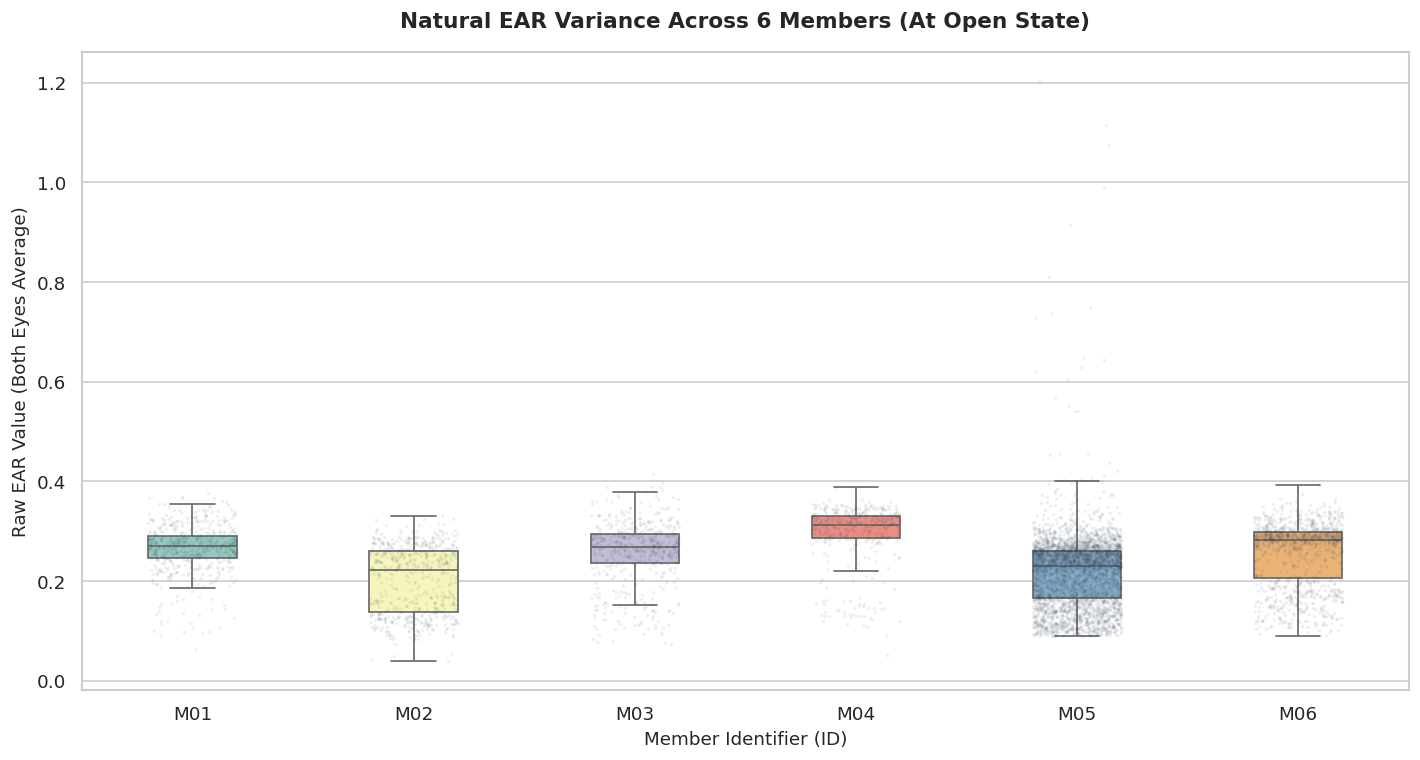


 📊 DESCRIPTIVE EAR STATS AT OPEN STATE (LABEL = 1) PER MEMBER
           Frame Count  Mean EAR  Median EAR  Min EAR  Max EAR
member_id                                                     
M01              562.0    0.2650      0.2696   0.0644   0.3757
M02              596.0    0.2029      0.2220   0.0403   0.3310
M03              528.0    0.2575      0.2688   0.0744   0.4147
M04              402.0    0.2931      0.3124   0.0506   0.3891
M05             3665.0    0.2173      0.2295   0.0900   1.2030
M06             1141.0    0.2573      0.2830   0.0902   0.3935



In [3]:

# Chỉ lọc các khung hình mở mắt (Label == 1) để đo kích thước hốc mắt nền
df_open_eyes = df_merged[df_merged['label'] == 1].sort_values('member_id')

# =========================================================================
# 🎨 PLOTTING CLEAN BOXPLOT + STRIPPLOT (VẼ ĐỒ THỊ HỘP SẠCH)
# =========================================================================
plt.figure(figsize=(12, 6.5), dpi=120)

# Vẽ boxplot nền
sns.boxplot(data=df_open_eyes, x='member_id', y='ear_left', hue='member_id', palette='Set3', width=0.4, fliersize=0, legend=False)
# Phủ stripplot mờ phía sau để thấy mật độ phân phối thực tế của từng frame ảnh
sns.stripplot(data=df_open_eyes, x='member_id', y='ear_left', color='#2c3e50', size=2, alpha=0.08, jitter=0.2)

plt.title('Natural EAR Variance Across 6 Members (At Open State)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Member Identifier (ID)', fontsize=11)
plt.ylabel('Raw EAR Value (Both Eyes Average)', fontsize=11)
plt.tight_layout()

# Lưu ảnh sạch vào thư mục
plt.savefig(os.path.join(OUTPUT_DIR, 'step3_open_state_ear_boxplot.png'), bbox_inches='tight')
plt.show()

# =========================================================================
# 📊 PRINT SỐ LIỆU XUẤT RA DƯỚI ĐỒ THỊ TỬ TẾ (DESCRIPTIVE STATS)
# =========================================================================
print("\n" + "="*85)
print(" 📊 DESCRIPTIVE EAR STATS AT OPEN STATE (LABEL = 1) PER MEMBER")
print("="*85)
desc_stats = df_open_eyes.groupby('member_id')['ear_left'].describe().round(4)
desc_stats.columns = ['Frame Count', 'Mean EAR', 'Std Dev', 'Min EAR', '25%', 'Median EAR', '75%', 'Max EAR']
print(desc_stats[['Frame Count', 'Mean EAR', 'Median EAR', 'Min EAR', 'Max EAR']])
print("="*85 + "\n")

## 4. Static Threshold Optimization & Spatiotemporal Counter-Argument
*Objective: Calculating the optimal static boundary via ROC-AUC and evaluating its real-time deployment constraints.*

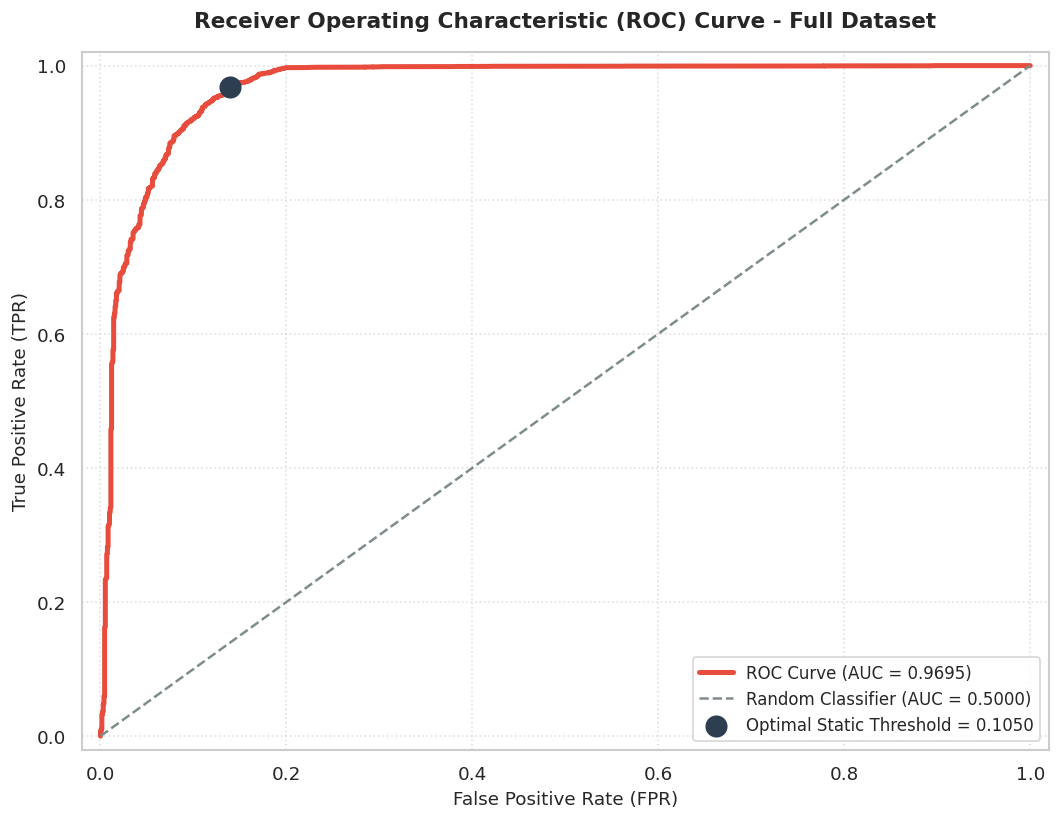


     📊 MATHEMATICAL STATIC THRESHOLD OPTIMIZATION (FULL DATASET)     
 • Model Discriminating Power (AUC Score) : 0.9695
 • Optimal Static EAR Boundary Classification : 0.1050
 • True Positive Rate (TPR) at Threshold   : 96.88%
 • False Positive Rate (FPR) at Threshold  : 13.96%
----------------------------------------------------------------------


In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import roc_curve, auc

# Tính toán các thông số ROC dựa trên toàn bộ Dataset gốc (Giữ nguyên M05)
fpr, tpr, thresholds = roc_curve(df_merged['label'], df_merged['ear_left'])
roc_auc = auc(fpr, tpr)

# Tìm ngưỡng tĩnh tối ưu bằng Youden's J Index (J = TPR - FPR)
idx_optimal = np.argmax(tpr - fpr)
optimal_threshold = thresholds[idx_optimal]

# =========================================================================
# 🎨 PLOTTING SINGLE CLEAN ROC CURVE (VẼ 1 BIỂU ĐỒ ROC ĐƠN SẠCH TINH TƯƠM)
# =========================================================================
plt.figure(figsize=(9, 7), dpi=120)

# Vẽ đường cong ROC chính
plt.plot(fpr, tpr, color='#e74c3c', lw=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')

# Vẽ đường phân loại ngẫu nhiên (Random Baseline)
plt.plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.5000)')

# Chấm điểm Ngưỡng tĩnh tối ưu (Optimal Threshold Point)
plt.scatter(fpr[idx_optimal], tpr[idx_optimal], color='#2c3e50', marker='o', s=150, zorder=5, 
            label=f'Optimal Static Threshold = {optimal_threshold:.4f}')

# Cấu hình các chi tiết học thuật trên đồ thị
plt.title('Receiver Operating Characteristic (ROC) Curve - Full Dataset', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR)', fontsize=11)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="lower right", frameon=True, fontsize=10)
plt.tight_layout()

# Lưu bản ảnh đơn sạch vào thư mục cấu hình
plt.savefig(os.path.join(OUTPUT_DIR, 'step4_single_roc_curve.png'), bbox_inches='tight')
plt.show()

# =========================================================================
# 📊 PRINT CLEAN SUMMARY REPORT (IN SỐ LIỆU CHÚ THÍCH RA NGOÀI TỬ TẾ)
# =========================================================================
print("\n" + "="*70)
print("     📊 MATHEMATICAL STATIC THRESHOLD OPTIMIZATION (FULL DATASET)     ")
print("="*70)
print(f" • Model Discriminating Power (AUC Score) : {roc_auc:.4f}")
print(f" • Optimal Static EAR Boundary Classification : {optimal_threshold:.4f}")
print(f" • True Positive Rate (TPR) at Threshold   : {tpr[idx_optimal]*100:.2f}%")
print(f" • False Positive Rate (FPR) at Threshold  : {fpr[idx_optimal]*100:.2f}%")
print("-"*70)

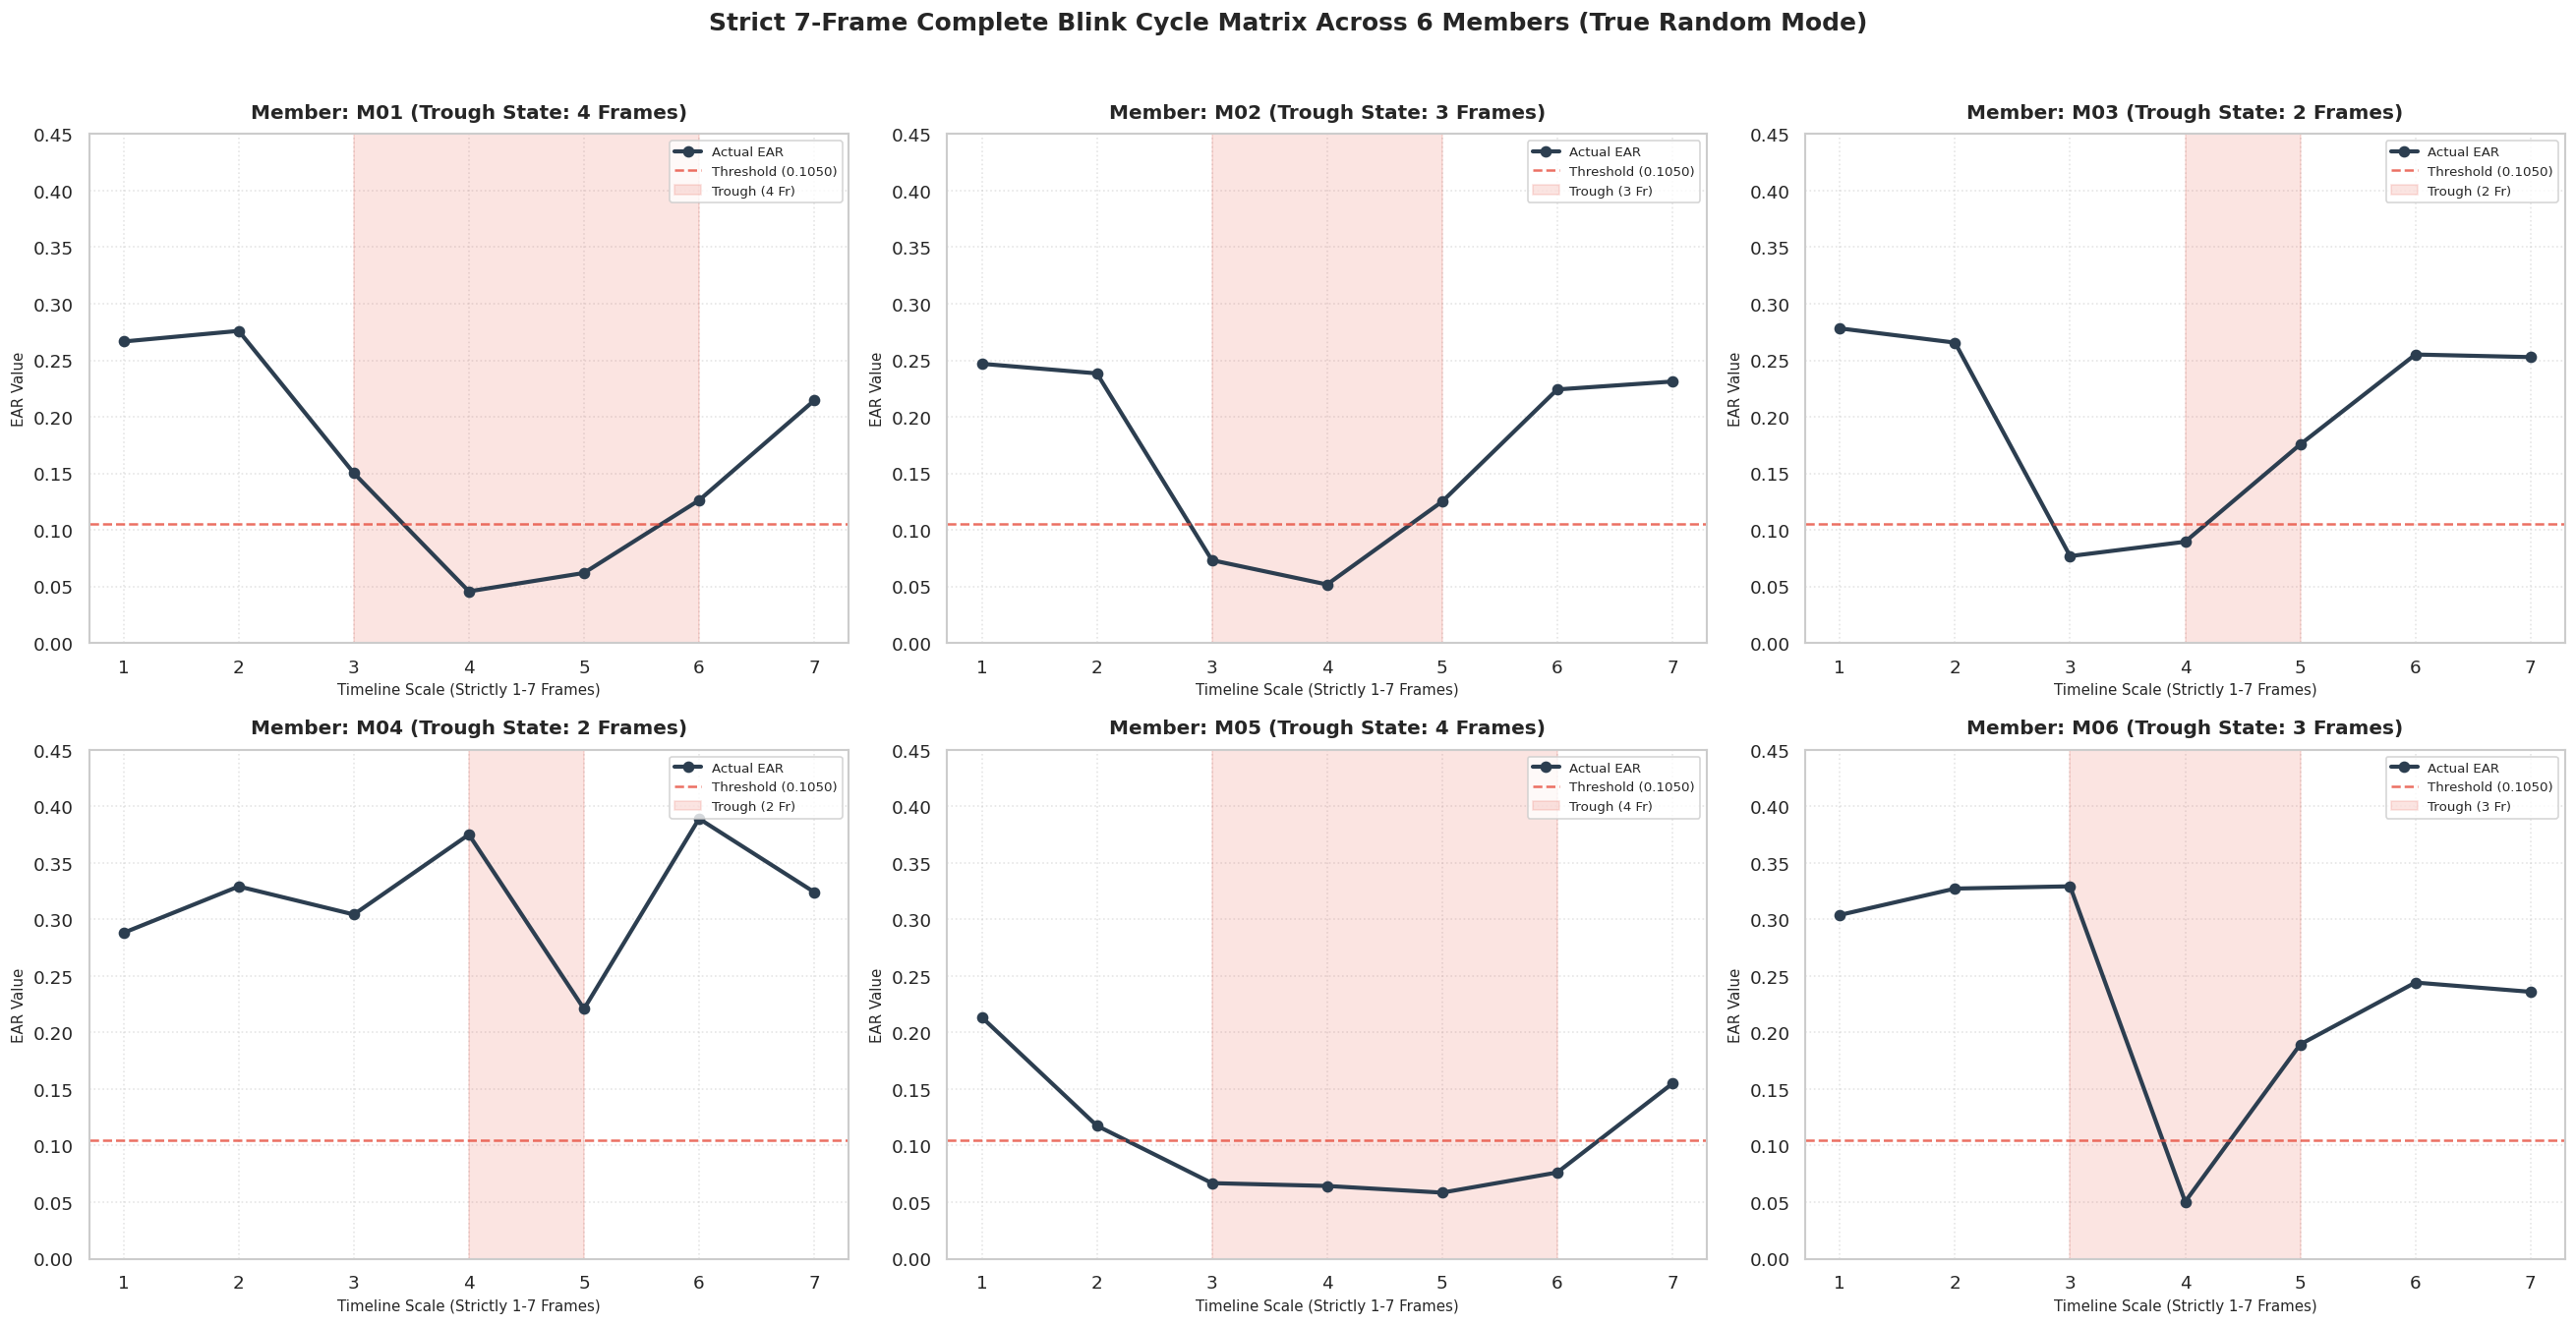

In [78]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

all_members = ['M01', 'M02', 'M03', 'M04', 'M05', 'M06']

fig, axes = plt.subplots(2, 3, figsize=(22, 11), dpi=120)
axes = axes.flatten()

# Lọc kho mẫu các chuỗi nhắm mắt ngắn (từ 2 đến 4 frames)
short_blink_pool = closed_sequences[
    (closed_sequences['consecutive_frames'] >= 2) & 
    (closed_sequences['consecutive_frames'] <= 4)
].copy()
short_blink_pool['member_id'] = short_blink_pool['video_id'].apply(lambda x: x.split('_')[0])

for idx, member in enumerate(all_members):
    member_pool = short_blink_pool[short_blink_pool['member_id'] == member].reset_index(drop=True)
    
    if len(member_pool) == 0:
        member_pool = closed_sequences[
            (closed_sequences['video_id'].str.startswith(member)) & 
            (closed_sequences['consecutive_frames'] <= 6)
        ].reset_index(drop=True)
    
    # 🎯 SỬA LỖI: Chọn ngẫu nhiên thực sự bằng .sample() và KHÔNG dùng seed khóa kết quả
    sample_seq = member_pool.sample(n=1).iloc[0]
    
    v_id = sample_seq['video_id']
    b_id = sample_seq['block_id']
    trough_duration = sample_seq['consecutive_frames']
    
    video_data = df_ts[df_ts['video_id'] == v_id].sort_values('frame_index').reset_index(drop=True)
    blink_indices = video_data[video_data['block_id'] == b_id].index
    
    # Thuật toán ép khít 7 frames
    center_idx = int(np.median(blink_indices.to_numpy()))
    start_idx = center_idx - 3
    end_idx = center_idx + 4
    
    exact_7fr_data = video_data.iloc[start_idx:end_idx].copy()
    exact_7fr_data['relative_frame'] = range(1, 8)
    
    # Vẽ đồ thị
    ax = axes[idx]
    ax.plot(exact_7fr_data['relative_frame'], exact_7fr_data['ear_left'], 
            color='#2c3e50', linestyle='-', marker='o', lw=2.5, markersize=6, label='Actual EAR')
    
    ax.axhline(y=0.1050, color='#e74c3c', linestyle='--', alpha=0.8, lw=1.5, label='Threshold (0.1050)')
    
    closed_area = exact_7fr_data[exact_7fr_data['block_id'] == b_id]
    if not closed_area.empty:
        ax.axvspan(closed_area['relative_frame'].min(), closed_area['relative_frame'].max(), 
                   color='#e74c3c', alpha=0.15, label=f'Trough ({trough_duration} Fr)')
        
    ax.set_title(f'Member: {member} (Trough State: {trough_duration} Frames)', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Timeline Scale (Strictly 1-7 Frames)', fontsize=9)
    ax.set_ylabel('EAR Value', fontsize=9)
    ax.set_ylim([0.0, 0.45])
    ax.set_xticks(range(1, 8))
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Strict 7-Frame Complete Blink Cycle Matrix Across 6 Members (True Random Mode)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'step1_6_members_strict_7frame_matrix.png'), bbox_inches='tight')
plt.show()

